In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial

from qiskit import Aer, BasicAer
from qiskit.utils import QuantumInstance, algorithm_globals
from qiskit.algorithms.optimizers import SLSQP, COBYLA
from qiskit.algorithms.minimum_eigen_solvers import NumPyMinimumEigensolver, VQE
from qiskit.circuit.library import ExcitationPreserving

from qiskit_nature.problems.second_quantization import ElectronicStructureProblem
from qiskit_nature.converters.second_quantization import QubitConverter
from qiskit_nature.mappers.second_quantization import JordanWignerMapper, ParityMapper
from qiskit_nature.algorithms import GroundStateEigensolver
from qiskit_nature.drivers import UnitsType, Molecule
from qiskit_nature.drivers.second_quantization import ElectronicStructureDriverType, ElectronicStructureMoleculeDriver
from qiskit_nature.drivers.second_quantization import FCIDumpDriver
from qiskit_nature.operators.second_quantization import FermionicOp
from qiskit_nature.algorithms.pes_samplers import BOPESSampler, Extrapolator

import warnings
warnings.simplefilter("ignore", np.RankWarning)
algorithm_globals.random_seed = 75

In [2]:
#path = r"/home/ola/quantum_computing/test/h2/chronus/FCIDUMP"
path = r"/home/ola/quantum_computing/RbH/opfermion/example/FCIDUMP"
driver = FCIDumpDriver(path, relativistic=True)

In [3]:
def index_to_op_label(tuple_index, shift=None):
    r"""
    Converts a liste of indices to qiskit string representation of a second-quantized operator.
    Assumes a chemical notation of integrals.
    tuple_index : tuple of integers
    
    """
    if shift and len(tuple_index)!=len(shift):
        raise ValueError(f"Condition not satisfied: len({tuple_index})!=len({shift}) (expected equal).")
    if not shift:
        shift = [0] * len(tuple_index)
    n = len(tuple_index)
    if n==4:
        tuple_index = (tuple_index[0], tuple_index[2], tuple_index[1], tuple_index[3])
    op_label = ""
    for i, (p, s) in enumerate(zip(tuple_index, shift)):
        if i<n//2:
            #print("creation")
            op_label += f"+_{p+s} "
        else:
            #print("annihilation")
            op_label += f"-_{p+s} "
    return op_label[:-1]


def test_index_to_op_label():
    assert index_to_op_label((0, 2))=="+_1 -_2", f"Expected: +_1 -_2, obtained: {index_to_op_label((1, 2))}"
    assert index_to_op_label((0, 2, 3, 4))=="+_1 +_3 -_2 -_4", f"Expected: +_1 +_3 -_2 -_4, obtained: {index_to_op_label((1, 2, 3, 4))}"

#test_index_to_op_label()

In [4]:
problem = ElectronicStructureProblem(driver=driver)
qubit_converter = QubitConverter(JordanWignerMapper(), two_qubit_reduction=False)

quantum_instance = QuantumInstance(backend=Aer.get_backend("aer_simulator_statevector"))
# ansatz = UCCSD(qubit_converter=None, num_particles=None, num_spin_orbitals=None, reps=1, initial_state=None, generalized=False, preserve_spin=True)

# solver = VQE(ansatz=None, optimizer=None, initial_point=None, gradient=None, expectation=None, include_custom=False, max_evals_grouped=1, callback=None, quantum_instance=None)
#solver = VQE(quantum_instance=quantum_instance)
solver = NumPyMinimumEigensolver()

# groundstate = GroundStateEigensolver(qubit_converter, solver)
ground = GroundStateEigensolver(qubit_converter, solver)


In [5]:
second_q_ops = problem.second_q_ops()
print("type(second_q_ops) =", type(second_q_ops))
print("Number of particles ", problem.num_particles)
print("Number of spin-orbitals ", problem.num_spin_orbitals)
#print(dir(second_q_ops))

spinor_int_list = second_q_ops[0].to_list()
spinor_int_list.sort(key=lambda x: x[0])
spinor_int_list.sort(key=lambda x: len(x[0]))
with open("./second_q_op.txt", "w+") as f:
    for term in spinor_int_list:
        print(term[0], term[1])
        f.write(str(term[0]) + " " + str(term[1]) + "\n")

We have relativistic calculations: True
type(second_q_ops) = <class 'list'>
Number of particles  (1, 1)
Number of spin-orbitals  4
+_0 -_0 (-0.6759033389058856+9.83185745169535e-24j)
+_0 -_1 (0.03321213550639889-8.918651939849311e-10j)
+_0 -_3 (7.172139930206994e-10-1.7829929565979644e-10j)
+_1 -_0 (0.03321213550639858+8.918651939849628e-10j)
+_1 -_1 (-0.19101205553330144-3.136864368844282e-24j)
+_1 -_2 (-7.172139930206971e-10+1.7829929565979848e-10j)
+_2 -_1 (-7.172139930206994e-10-1.7829929565979644e-10j)
+_2 -_2 (-0.6759033389058856-9.83185745169535e-24j)
+_2 -_3 (0.03321213550639889+8.918651939849311e-10j)
+_3 -_0 (7.172139930206971e-10+1.7829929565979848e-10j)
+_3 -_2 (0.03321213550639858-8.918651939849628e-10j)
+_3 -_3 (-0.19101205553330144+3.136864368844282e-24j)
+_0 +_0 -_0 -_0 (0.2205727750262106-3.636463883794203e-29j)
+_0 +_0 -_0 -_1 (-0.016606067725280445+4.379909455763466e-10j)
+_0 +_0 -_0 -_3 (-3.562816789279175e-10+8.086826306254045e-11j)
+_0 +_0 -_1 -_0 (-0.016606067725

In [6]:
from qiskit_nature.algorithms import GroundStateEigensolver

calc = GroundStateEigensolver(qubit_converter, solver)
res = calc.solve(problem)

We have relativistic calculations: True


In [7]:
print(res)

=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -0.916439646944
  - computed part:      -0.916439646944
~ Nuclear repulsion energy (Hartree): -2979.452282359914
> Total ground state energy (Hartree): -2980.368722006857


In [8]:
for i in dir(res):
    if i[0]!="_":
        print(i)

aux_operator_eigenvalues
combine
computed_dipole_moment
computed_energies
dipole_moment
dipole_moment_in_debye
eigenenergies
eigenstates
electronic_dipole_moment
electronic_energies
extracted_transformer_dipole
extracted_transformer_dipoles
extracted_transformer_energies
extracted_transformer_energy
formatted
groundenergy
groundstate
hartree_fock_energy
has_dipole
has_observables
magnetization
nuclear_dipole_moment
nuclear_repulsion_energy
num_particles
raw_result
reverse_dipole_sign
spin
total_angular_momentum
total_dipole_moment
total_dipole_moment_in_debye
total_energies


In [9]:
res.eigenenergies

array([-0.91643965+2.56422204e-17j])

In [10]:
res.computed_energies

array([-0.91643965])

In [11]:
res.total_energies

array([-2980.36872201+0.j])

In [12]:
# Make relativistic parser for FCIDUMP files
from typing import Any, Dict, Set, Tuple, Iterator

def parse_rel(fcidump: str) -> Dict[str, Any]:
    """Parses a FCIDump output.

    Args:
        fcidump: Path to the FCIDump file.
    Raises:
        QiskitNatureError: If the input file cannot be found, if a required field in the FCIDump
            file is missing, if wrong integral indices are encountered, or if the alpha/beta or
            beta/alpha 2-electron integrals are mixed.
    Returns:
        A dictionary storing the parsed data.
    """
    try:
        with open(fcidump, "r", encoding="utf8") as file:
            fcidump_str = file.read()
    except OSError as ex:
        raise QiskitNatureError(f"Input file '{fcidump}' cannot be read!") from ex

    output = {}  # type: Dict[str, Any]

    # FCIDump starts with a Fortran namelist of meta data
    namelist_end = re.search("(/|&END)", fcidump_str)
    metadata = fcidump_str[: namelist_end.start(0)]
    metadata = " ".join(metadata.split())  # replace duplicate whitespace and newlines
    # we know what elements to look for so we don't get too fancy with the parsing
    # pattern explanation:
    #  .*?      any text
    #  (*|*),   match either part of this group followed by a comma
    #  [-+]?    match up to a single - or +
    #  \d*.\d+  number format
    pattern = r".*?([-+]?\d*\.\d+|[-+]?\d+),"
    # we parse the values in the order in which they are listed in Knowles1989
    _norb = re.search("NORB" + pattern, metadata)
    if _norb is None:
        raise QiskitNatureError("The required NORB entry of the FCIDump format is missing!")
    norb = int(_norb.groups()[0])
    output["NORB"] = norb
    if norb%2 != 0:
        raise ValueError(f"NORB = {output['NORB']}\nOnly even number of spinors is supported!")
    _nelec = re.search("NELEC" + pattern, metadata)
    if _nelec is None:
        raise QiskitNatureError("The required NELEC entry of the FCIDump format is missing!")
    output["NELEC"] = int(_nelec.groups()[0])
    # the rest of these values may occur and are set to their defaults otherwise
    _ms2 = re.search("MS2" + pattern, metadata)
    output["MS2"] = int(_ms2.groups()[0]) if _ms2 else 0
    _isym = re.search("ISYM" + pattern, metadata)
    output["ISYM"] = int(_isym.groups()[0]) if _isym else 1
    # ORBSYM holds a list, thus it requires a little different treatment
    _orbsym = re.search(r"ORBSYM.*?" + r"(\d+)," * norb, metadata)
    output["ORBSYM"] = [int(s) for s in _orbsym.groups()] if _orbsym else [1] * norb
    _iprtim = re.search("IPRTIM" + pattern, metadata)
    output["IPRTIM"] = int(_iprtim.groups()[0]) if _iprtim else -1
    _int = re.search("INT" + pattern, metadata)
    output["INT"] = int(_int.groups()[0]) if _int else 5
    _core = re.search("CORE" + pattern, metadata)
    output["CORE"] = float(_core.groups()[0]) if _core else 0.0
    _maxit = re.search("MAXIT" + pattern, metadata)
    output["MAXIT"] = int(_maxit.groups()[0]) if _maxit else 25
    _thr = re.search("THR" + pattern, metadata)
    output["THR"] = float(_thr.groups()[0]) if _thr else 1e-5
    _thrres = re.search("THRRES" + pattern, metadata)
    output["THRRES"] = float(_thrres.groups()[0]) if _thrres else 0.1
    _nroot = re.search("NROOT" + pattern, metadata)
    output["NROOT"] = int(_nroot.groups()[0]) if _nroot else 1

    # the rest of the FCIDump will hold lines of the form x i a j b
    # a few cases have to be treated differently:
    # i, a, j and b are all zero: x is the core energy
    # TODO: a, j and b are all zero: x is the energy of the i-th MO  (often not supported)
    # j and b are both zero: x is the 1e-integral between i and a (x = <i|h|a>)
    # otherwise: x is the Coulomb integral ( x = (ia|jb) )
    # h: one-body integrals with non-redundant blocks: aa, ab, ba
    # g: two-body integrals with non-redundant blocks aaaa, baaa, abaa, baab, baba, abab
    # "a" correspond to unbarred Hamiltonian elements while "b" stands for barred elements
    # Jensen et al.: Relativistic four-component MCSCF theory, J. Chem. Phys., Vol. 104, No. 11, 1996
    dtype = complex
    # Initalize one-body elements
    h = {}
    for block in ["aa", "ab", "ba"]:
        h[block] = np.zeros((norb//2, norb//2), dtype=dtype)
        #print(f"shape of h_{block} = {h[block].shape}")
    # Initalize two-body elements
    g = {}
    for block in ["aaaa", "baaa", "abaa", "baab", "baba", "abab"]:
        g[block] = np.zeros((norb//2, norb//2, norb//2, norb//2), dtype=dtype)
        #print(f"shape of g_{block} = {g[block].shape}")

    # Read data
    orbital_data = fcidump_str[namelist_end.end(0) :].split("\n")
    for orbital in orbital_data:
        if not orbital:
            continue
        if len(orbital.split())==6:
            a = float(orbital.split()[0])
            b = float(orbital.split()[1])
            x = complex(a, b)
            i, a, j, b = [int(i) for i in orbital.split()[2:]]
        elif "," not in orbital.split()[0]:
            x = float(orbital.split()[0])
            i, a, j, b = [int(i) for i in orbital.split()[1:]]
        else:
            raise ValueError(f"Do not know how to interpret a line {orbital}.")    
        #print(x, i, a, j, b)
        # Note: differing naming than ijkl due to E741 and this iajb is inline with this:
        # https://hande.readthedocs.io/en/latest/manual/integrals.html#fcidump-format
        #i, a, j, b = [int(i) for i in orbital.split()[1:]]
        #print(f"Found element: {x} {i} {a} {j} {b}")
        #raise ValueError("Good")
        if i == a == j == b == 0:
            output["ecore"] = x
        elif a == j == b == 0:
            # TODO: x is the energy of the i-th MO
            continue
        elif j == b == 0:
            if i <= norb/2 and a <= norb/2: # this is aa block
                h["aa"][i-1, a-1] = x
                #print(f"added {i} {a} element to aa block")
            elif i <= norb/2 and a > norb/2:
                h["ab"][i-1, a-1-norb//2] = x
                #print(f"added {i} {a} element to ab block")
            elif i > norb/2 and a <= norb/2:
                h["ba"][i-1-norb//2, a-1] = x
                #print(f"added {i} {a} element to ba block")
        else:
            if i <= norb/2 and a <= norb/2 and j <= norb/2 and b <= norb/2:
                g["aaaa"][i-1, a-1, j-1, b-1] = x
                #print(f"added {i} {a} {j} {b} element to aaaa block")
            elif i > norb/2 and a <= norb/2 and j <= norb/2 and b <= norb/2:
                g["baaa"][i-1-norb//2, a-1, j-1, b-1] = x
            elif i <= norb/2 and a > norb/2 and j <= norb/2 and b <= norb/2:
                g["abaa"][i-1, a-1-norb//2, j-1, b-1] = x
            elif i > norb/2 and a <= norb/2 and j <= norb/2 and b > norb/2:
                g["baab"][i-1-norb//2, a-1, j-1, b-1-norb//2] = x
            elif i > norb/2 and a <= norb/2 and j > norb/2 and b <= norb/2:
                g["baba"][i-1-norb//2, a-1, j-1-norb//2, b-1] = x
            elif i <= norb/2 and a > norb/2 and j <= norb/2 and b > norb/2:
                g["abab"][i-1, a-1-norb//2, j-1, b-1-norb//2] = x
                #print(f"added {i} {a} {j} {b} element to abab block")

    output["h"] = h
    output["g"] = g

    #print("\nOne-body H\n", hij)
    #print("\nTwo-body H\n", hijkl)
    #from numpy import savez_compressed
    #savez_compressed("/home/ola/quantum_computing/RbH/opfermion/example/eri.npz", hijkl)
    #raise ValueError("Error implemented just to stop code in this point.")

    return output

fcidump = parse_rel(path)
fcidump.keys()

dict_keys(['NORB', 'NELEC', 'MS2', 'ISYM', 'ORBSYM', 'IPRTIM', 'INT', 'CORE', 'MAXIT', 'THR', 'THRRES', 'NROOT', 'ecore', 'h', 'g'])

In [13]:
# These are terms from Eqs. (2.19) and (2.20) in  J. Chem. Phys. 104, 4083 (1996)
# They include only permutations but no factor

NP = fcidump["NORB"] // 2

def Xaa(p, q):
    return [(p, q), (p+NP, q+NP)]

def Xab(p, q):
    return [(p, q+NP), (q, p+NP)]

def Xba(p, q):
    return [(p+NP, q), (q+NP, p)]

def Xaaaa(p, q, r, s):
    return [
        (p, r, s, q),
        (q+NP, r, s, p+NP),
        (p, s+NP, r+NP, q),
        (q+NP, s+NP, r+NP, p+NP)
        ]

def Xbaaa(p, q, r, s):
    """factor_a"""
    return [
        (p+NP, r, s, q),
        (q+NP, r, s, p),
        (p+NP, s+NP, r+NP, q),
        (q+NP, s+NP, r+NP, p)
        ]

def Xabaa(p, q, r, s):
    """factor_a"""
    return [
        (p, r, s, q+NP),
        (q, r, s, p+NP),
        (p, s+NP, r+NP, q+NP),
        (q, s+NP, r+NP, p+NP)
        ]

def Xbaab(p, q, r, s):
    """factor_b"""
    return [
        (p+NP, r, s+NP, q),
        (q+NP, r, s+NP, p),
        (p+NP, s, r+NP, q),
        (q+NP, s, r+NP, p)
        ]

def Xbaba(p, q, r, s):
    """factor_b"""
    return [
        (p+NP, r+NP, s, q),
        (q+NP, r+NP, s, p),
        (p+NP, s+NP, r, q),
        (q+NP, s+NP, r, p)
        ]

def Xabab(p, q, r, s):
    """factor_b"""
    return [
        (p, r, s+NP, q+NP),
        (q, r, s+NP, p+NP),
        (p, s, r+NP, q+NP),
        (q, s, r+NP, p+NP)
        ]


In [14]:
#from operator import index

ind2op = index_to_op_label
npair = fcidump["NORB"] // 2

i_list = []

i_list += [(ind2op(Xaa(*index)[0]), value) for index, value in np.ndenumerate(fcidump["h"]["aa"])]
i_list += [(ind2op(Xaa(*index)[1]), value) for index, value in np.ndenumerate(fcidump["h"]["aa"])]

i_list += [(ind2op(Xab(*index)[0]), value/2) for index, value in np.ndenumerate(fcidump["h"]["ab"])]
i_list += [(ind2op(Xab(*index)[1]), -value/2) for index, value in np.ndenumerate(fcidump["h"]["ab"])]

i_list += [(ind2op(Xba(*index)[0]), value/2) for index, value in np.ndenumerate(fcidump["h"]["ba"])]
i_list += [(ind2op(Xba(*index)[1]), -value/2) for index, value in np.ndenumerate(fcidump["h"]["ba"])]

i_list += [(ind2op(Xaaaa(*index)[0]), value/2) for index, value in np.ndenumerate(fcidump["g"]["aaaa"])]
i_list += [(ind2op(Xaaaa(*index)[1]), value/2) for index, value in np.ndenumerate(fcidump["g"]["aaaa"])]
i_list += [(ind2op(Xaaaa(*index)[2]), value/2) for index, value in np.ndenumerate(fcidump["g"]["aaaa"])]
i_list += [(ind2op(Xaaaa(*index)[3]), value/2) for index, value in np.ndenumerate(fcidump["g"]["aaaa"])]

i_list += [(ind2op(Xbaaa(*index)[0]), value/2) for index, value in np.ndenumerate(fcidump["g"]["baaa"])]
i_list += [(ind2op(Xbaaa(*index)[1]), -value/2) for index, value in np.ndenumerate(fcidump["g"]["baaa"])]
i_list += [(ind2op(Xbaaa(*index)[2]), value/2) for index, value in np.ndenumerate(fcidump["g"]["baaa"])]
i_list += [(ind2op(Xbaaa(*index)[3]), -value/2) for index, value in np.ndenumerate(fcidump["g"]["baaa"])]

i_list += [(ind2op(Xabaa(*index)[0]), value/2) for index, value in np.ndenumerate(fcidump["g"]["abaa"])]
i_list += [(ind2op(Xabaa(*index)[1]), -value/2) for index, value in np.ndenumerate(fcidump["g"]["abaa"])]
i_list += [(ind2op(Xabaa(*index)[2]), value/2) for index, value in np.ndenumerate(fcidump["g"]["abaa"])]
i_list += [(ind2op(Xabaa(*index)[3]), -value/2) for index, value in np.ndenumerate(fcidump["g"]["abaa"])]

i_list += [(ind2op(Xbaab(*index)[0]), value/4) for index, value in np.ndenumerate(fcidump["g"]["baab"])]
i_list += [(ind2op(Xbaab(*index)[1]), -value/4) for index, value in np.ndenumerate(fcidump["g"]["baab"])]
i_list += [(ind2op(Xbaab(*index)[2]), -value/4) for index, value in np.ndenumerate(fcidump["g"]["baab"])]
i_list += [(ind2op(Xbaab(*index)[3]), value/4) for index, value in np.ndenumerate(fcidump["g"]["baab"])]

i_list += [(ind2op(Xbaba(*index)[0]), value/8) for index, value in np.ndenumerate(fcidump["g"]["baba"])]
i_list += [(ind2op(Xbaba(*index)[1]), -value/8) for index, value in np.ndenumerate(fcidump["g"]["baba"])]
i_list += [(ind2op(Xbaba(*index)[2]), -value/8) for index, value in np.ndenumerate(fcidump["g"]["baba"])]
i_list += [(ind2op(Xbaba(*index)[3]), value/8) for index, value in np.ndenumerate(fcidump["g"]["baba"])]

i_list += [(ind2op(Xabab(*index)[0]), value/8) for index, value in np.ndenumerate(fcidump["g"]["abab"])]
i_list += [(ind2op(Xabab(*index)[1]), -value/8) for index, value in np.ndenumerate(fcidump["g"]["abab"])]
i_list += [(ind2op(Xabab(*index)[2]), -value/8) for index, value in np.ndenumerate(fcidump["g"]["abab"])]
i_list += [(ind2op(Xabab(*index)[3]), value/8) for index, value in np.ndenumerate(fcidump["g"]["abab"])]

int_list_original = [i for i in i_list if np.abs(i[1]) > 1e-12]
int_list = []

int_dict = {}
for i in int_list_original:
    if i[0] not in int_dict:
        int_dict[i[0]] = i[1]
    else:
        int_dict[i[0]] += i[1]

for index, value in int_dict.items():
    int_list.append((index, value))

int_list.sort(key=lambda x: x[0])
int_list.sort(key=lambda x: len(x[0]))

with open("./kramer_q_op.txt", "w+") as f:
    for term in int_list:
        f.write(str(term[0]) + " " + str(term[1]) + "\n")
int_list[:25]
#int_list#[0:10]

[('+_0 -_0', (-0.6759033389058856+9.83185745169535e-24j)),
 ('+_0 -_1', (0.03321213550639889-8.918651939849311e-10j)),
 ('+_0 -_3', (7.172139930206982e-10-1.7829929565979747e-10j)),
 ('+_1 -_0', (0.03321213550639858+8.918651939849628e-10j)),
 ('+_1 -_1', (-0.19101205553330144-3.136864368844282e-24j)),
 ('+_1 -_2', (-7.172139930206982e-10+1.7829929565979747e-10j)),
 ('+_2 -_1', (-7.172139930206982e-10-1.7829929565979747e-10j)),
 ('+_2 -_2', (-0.6759033389058856+9.83185745169535e-24j)),
 ('+_2 -_3', (0.03321213550639889-8.918651939849311e-10j)),
 ('+_3 -_0', (7.172139930206982e-10+1.7829929565979747e-10j)),
 ('+_3 -_2', (0.03321213550639858+8.918651939849628e-10j)),
 ('+_3 -_3', (-0.19101205553330144-3.136864368844282e-24j)),
 ('+_0 +_0 -_0 -_0', (0.2205727750262106-3.636463883794203e-29j)),
 ('+_0 +_0 -_0 -_1', (-0.016606067725280445+4.379909455763466e-10j)),
 ('+_0 +_0 -_0 -_3', (-7.125633578558351e-10+1.617365261250809e-10j)),
 ('+_0 +_0 -_1 -_0', (-0.01660606772528047-4.3799087270115

In [ ]:
from my_research import fermionic_operator_from_fcidump

fermionic_operator_from_fcidump(fcidump)

FermionicOp([('+_0 -_0', (-0.6759033389058856+9.83185745169535e-24j)), ('+_0 -_1', (0.03321213550639889-8.918651939849311e-10j)), ('+_0 -_3', (7.172139930206982e-10-1.7829929565979747e-10j)), ('+_1 -_0', (0....)], register_length=4, display_format='sparse')

In [16]:
from qiskit_nature.operators.second_quantization import FermionicOp
kramer_basis_hamiltonian = FermionicOp(int_list)
kramer_basis_hamiltonian.num_qubits = fcidump["NORB"]
#for term in kramer_basis_hamiltonian.terms():
#    print(term)
print(dir(kramer_basis_hamiltonian))

['_ATOL_DEFAULT', '_MAX_TOL', '_RTOL_DEFAULT', '__abstractmethods__', '__add__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__invert__', '__le__', '__len__', '__lt__', '__matmul__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__pow__', '__radd__', '__reduce__', '__reduce_ex__', '__repr__', '__rmul__', '__rsub__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__sub__', '__subclasshook__', '__truediv__', '__weakref__', '_abc_impl', '_data', '_display_format', '_multiply', '_register_length', '_substituted_label', '_to_dense_label_data', '_truncate', 'add', 'adjoint', 'atol', 'compose', 'display_format', 'is_hermitian', 'mul', 'normal_ordered', 'num_qubits', 'one', 'power', 'reduce', 'register_length', 'rtol', 'set_truncation', 'simplify', 'terms', 'to_list', 'to_matrix', 'to_normal_order', 'zero']


In [17]:
with open("./kramers_q_op.txt", "w+") as f:
    for term in kramer_basis_hamiltonian.to_list():
        print(term[0], term[1])
        f.write(str(term[0]) + " " + str(term[1]) + "\n")

+_0 -_0 (-0.6759033389058856+9.83185745169535e-24j)
+_0 -_1 (0.03321213550639889-8.918651939849311e-10j)
+_0 -_3 (7.172139930206982e-10-1.7829929565979747e-10j)
+_1 -_0 (0.03321213550639858+8.918651939849628e-10j)
+_1 -_1 (-0.19101205553330144-3.136864368844282e-24j)
+_1 -_2 (-7.172139930206982e-10+1.7829929565979747e-10j)
+_2 -_1 (-7.172139930206982e-10-1.7829929565979747e-10j)
+_2 -_2 (-0.6759033389058856+9.83185745169535e-24j)
+_2 -_3 (0.03321213550639889-8.918651939849311e-10j)
+_3 -_0 (7.172139930206982e-10+1.7829929565979747e-10j)
+_3 -_2 (0.03321213550639858+8.918651939849628e-10j)
+_3 -_3 (-0.19101205553330144-3.136864368844282e-24j)
+_0 +_0 -_0 -_0 (0.2205727750262106-3.636463883794203e-29j)
+_0 +_0 -_0 -_1 (-0.016606067725280445+4.379909455763466e-10j)
+_0 +_0 -_0 -_3 (-7.125633578558351e-10+1.617365261250809e-10j)
+_0 +_0 -_1 -_0 (-0.01660606772528047-4.379908727011532e-10j)
+_0 +_0 -_1 -_1 (0.002095416454970827-4.1052678536302173e-17j)
+_0 +_0 -_1 -_3 (9.051544254969881e-11

In [18]:
# Relativistic Electronic Structure Problem

from functools import partial
from typing import cast, Callable, Dict, List, Optional, Tuple, Union

from qiskit.algorithms import EigensolverResult, MinimumEigensolverResult
from qiskit.opflow import PauliSumOp
from qiskit.opflow.primitive_ops import Z2Symmetries

from qiskit_nature.problems.second_quantization.base_problem import BaseProblem
from qiskit_nature.operators.second_quantization import SecondQuantizedOp
from qiskit_nature import ListOrDictType
from qiskit_nature.problems.second_quantization.electronic.builders.hopping_ops_builder import _build_qeom_hopping_ops
from qiskit_nature.results import EigenstateResult, ElectronicStructureResult
from qiskit_nature.properties.grouped_property import GroupedProperty
from qiskit_nature.properties.second_quantization.electronic.electronic_energy import ElectronicEnergy
from qiskit_nature.properties.second_quantization.electronic.particle_number import ParticleNumber

class RelElectronicStructureProblem(ElectronicStructureProblem):
    """ Relativistic version of ElectronicStructureProblem done in not very elegant way. """
    
    def __init__(self, operators: FermionicOp, fcidump: dict):
        self.driver = None
        self.operators = operators
        self.transformers = []
        self.data = fcidump

        self._molecule_data = None
        self._molecule_data_transformed = None

        self._grouped_property = None
        self._grouped_property_transformed = None

        self._main_property_name = "RelativisticElectronicEnergy"

    @property
    def num_particles(self) -> Tuple[int, int]:
        return self._np

    @property
    def num_spin_orbitals(self) -> int:
        """Returns the number of spin orbitals."""
        return self._so

    def second_q_ops(self) -> ListOrDictType[SecondQuantizedOp]:
        self._grouped_property = GroupedProperty("1")
        self._grouped_property.add_property(ParticleNumber(
            num_spin_orbitals=self.data["NORB"],
            num_particles=self.data["NELEC"]
        ))
        self._grouped_property_transformed = GroupedProperty("2")
        self._np = fcidump["NELEC"]
        self._so = fcidump["NORB"]
        return [self.operators, None]
    
    

In [19]:
from qiskit_nature.algorithms.ground_state_solvers.minimum_eigensolver_factories import MinimumEigensolverFactory

class RelGroundStateEigenSolver(GroundStateEigensolver):
    """ Relativistic GroundStateEigenSolver hacked """

    def solve(self, problem, operator=None):
        main_operator, _ = self.get_qubit_operators(problem, None)
        raw_mes_result = self._solver.compute_minimum_eigenvalue(main_operator, None)  # type: ignore
        result = problem.interpret(raw_mes_result)
        return result

    def get_qubit_operators(
        self,
        problem: BaseProblem,
        aux_operators: Optional[ListOrDictType[Union[SecondQuantizedOp, PauliSumOp]]] = None,
    ) -> Tuple[PauliSumOp, Optional[ListOrDictType[PauliSumOp]]]:
        """Gets the operator and auxiliary operators, and transforms the provided auxiliary operators"""
        # Note that ``aux_ops`` contains not only the transformed ``aux_operators`` passed by the
        # user but also additional ones from the transformation
        second_q_ops = problem.second_q_ops()
        if isinstance(second_q_ops, list):
            main_second_q_op = second_q_ops[0]
            aux_second_q_ops = second_q_ops[1:]
        else:
            raise ValueError(
                f"The main `SecondQuantizedOp` associated with the {name} property cannot be `None`."
            )
        main_operator = self._qubit_converter.convert(
            main_second_q_op,
            num_particles=problem.num_particles,
            sector_locator=problem.symmetry_sector_locator,
        )

        if isinstance(self._solver, MinimumEigensolverFactory):
            # this must be called after transformation.transform
            self._solver = self._solver.get_solver(problem, self._qubit_converter)
        # if the eigensolver does not support auxiliary operators, reset them
        if not self._solver.supports_aux_operators():
            aux_ops = None
        return main_operator, None


In [20]:
problem2 = RelElectronicStructureProblem(kramer_basis_hamiltonian, fcidump=fcidump)
calc2 = RelGroundStateEigenSolver(qubit_converter, solver)
res = calc2.solve(problem2, kramer_basis_hamiltonian)

In [21]:
print(res)

=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -0.916438954695
  - computed part:      -0.916438954695


# Reordering the orbitals

In [22]:
def new_index(index, norb):
   """ The default ordering of spinors in DIRAC assumes that A spinors go first. Qiskit prefers energy ordering.
   E.g., the indices (1, 2, 3, 4, 5, 6) corresponding to two A and two B spinors must be reordered to
   (1, 3, 5, 2, 4, 6).
   Index | Returned
   1       1
   2       3
   3       5
   4       2
   5       4
   6       6
   """
   npair = norb // 2
   indices_in = list(range(1, norb+1))
   indices_out = list(range(1, norb+1, 2)) + list(range(2, norb+1, 2))
   return indices_out[indices_in.index(index)]

def test_new_index():
   assert new_index(1, 4) == 1
   assert new_index(2, 4) == 3
   assert new_index(3, 4) == 2
   assert new_index(5, 6) == 4

test_new_index()


In [23]:
new_index = partial(new_index, norb=fcidump["NORB"])
new_int_list = []
for operator, value in int_list:
    new_operator = ""
    for char in operator:
        if char.isnumeric():
            new_operator += str(new_index(float(char)+1)-1)
        else:
            new_operator += char
    new_int_list.append((new_operator, value))
new_int_list

[('+_0 -_0', (-0.6759033389058856+9.83185745169535e-24j)),
 ('+_0 -_2', (0.03321213550639889-8.918651939849311e-10j)),
 ('+_0 -_3', (7.172139930206982e-10-1.7829929565979747e-10j)),
 ('+_2 -_0', (0.03321213550639858+8.918651939849628e-10j)),
 ('+_2 -_2', (-0.19101205553330144-3.136864368844282e-24j)),
 ('+_2 -_1', (-7.172139930206982e-10+1.7829929565979747e-10j)),
 ('+_1 -_2', (-7.172139930206982e-10-1.7829929565979747e-10j)),
 ('+_1 -_1', (-0.6759033389058856+9.83185745169535e-24j)),
 ('+_1 -_3', (0.03321213550639889-8.918651939849311e-10j)),
 ('+_3 -_0', (7.172139930206982e-10+1.7829929565979747e-10j)),
 ('+_3 -_1', (0.03321213550639858+8.918651939849628e-10j)),
 ('+_3 -_3', (-0.19101205553330144-3.136864368844282e-24j)),
 ('+_0 +_0 -_0 -_0', (0.2205727750262106-3.636463883794203e-29j)),
 ('+_0 +_0 -_0 -_2', (-0.016606067725280445+4.379909455763466e-10j)),
 ('+_0 +_0 -_0 -_3', (-7.125633578558351e-10+1.617365261250809e-10j)),
 ('+_0 +_0 -_2 -_0', (-0.01660606772528047-4.3799087270115

In [24]:
kramer_basis_hamiltonian3 = FermionicOp(int_list)
kramer_basis_hamiltonian3.num_qubits = fcidump["NORB"]

In [25]:
problem3 = RelElectronicStructureProblem(kramer_basis_hamiltonian3, fcidump=fcidump)
calc3 = RelGroundStateEigenSolver(qubit_converter, solver)
res3 = calc3.solve(problem3, kramer_basis_hamiltonian3)

In [26]:
print(res3)

=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -0.916438954695
  - computed part:      -0.916438954695


## Example calculations on Rb2 with CAS(2, 10)

In [27]:
# Get a list of FCIDUMP files for SbH with different bond length
root = r"/home/ola/quantum_computing/Rb2/freepj_casci2_10/"
molecules = [(float(d)/100, root + d + "/FCIDUMP") for d in os.listdir(root) if re.match("\d\d\d", d)]
molecules.sort(key=lambda x: x[0])

In [37]:
# TODO
# Exact energies for CAS(2, 10) with Numpy
from qiskit.algorithms import NumPyEigensolver

point_exc = []
energy_exact = []

for bond_length, fcidump_path in molecules:
    fcidump = parse_rel(fcidump_path)
    kramers_hamiltonian = fermionic_operator_from_fcidump(fcidump)
    problem2 = RelElectronicStructureProblem(kramers_hamiltonian, fcidump=fcidump)
    calc2 = RelGroundStateEigenSolver(qubit_converter, solver)
    result2 = calc2.solve(problem2, kramers_hamiltonian)
    point_exc.append(bond_length)
    energy_exact.append(float(result2.total_energies[0]) + fcidump["ecore"])


/home/ola/miniconda3/envs/qiskit037/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


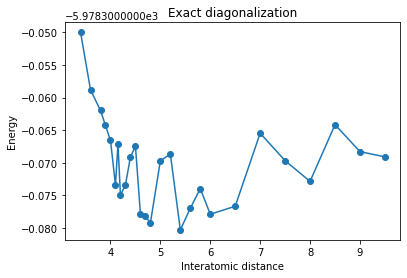

In [38]:
import matplotlib.pyplot as plt

plt.plot(point_exc, energy_exact, marker="o", label="ground")
plt.title("Exact diagonalization")
plt.xlabel("Interatomic distance")
plt.ylabel("Energy")
plt.savefig("/mnt/c/Users/Admin/Documents/Quantum_computing/out_Rb2.png")